## IMPORT

In [1]:
import pickle
import os
import re
import numpy as np


pickle_file = r"C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\IMPORT_DATA\EEG_PSD_CONNECTIVITY.pkl"

with open(pickle_file, 'rb') as f:
    eeg_psd_data_dict = pickle.load(f)

print(f"Num subjects: {len(eeg_psd_data_dict)}")
print(f"Keys of the first subject: {list(eeg_psd_data_dict[list(eeg_psd_data_dict.keys())[0]].keys())}")

Num subjects: 8
Keys of the first subject: ['subject_id', 'freqs', 'PSD', 'PSD_norm', 'PSD_all', 'PSD_norm_all']


In [3]:

load_path = r'C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\IMPORT_DATA'

with open(os.path.join(load_path, 'EEG_DATA_ALL.pkl'), 'rb') as f:
    EEG_DATA_ALL = pickle.load(f)

with open(os.path.join(load_path, 'EEG_DATA_ALL_EEG2EEG.pkl'), 'rb') as f:
    EEG_DATA_ALL_EEG2EEG = pickle.load(f)

with open(os.path.join(load_path, 'LFP_DATA_ALL.pkl'), 'rb') as f:
    LFP_DATA_ALL = pickle.load(f)

print("✅ All pickle files loaded successfully.")

# === Lista soggetti ===
subject_list = ['wue02', 'wue03', 'wue05', 'wue06', 'wue07', 'wue09', 'wue10', 'wue11']
left_handed_subjects = [subject_list[2], subject_list[5]]  # soggetti mancini

# === Funzione per fare mirror PSD ===
def mirror_psd(subject_id, data_dict, chan_names):
    """
    Esegue lo swap L/R dei canali per un soggetto nella struttura PSD.
    Gestisce:
      - PSD_all, PSD_norm_all : channels x trials x freqs
      - PSD, PSD_norm        : freqs x channels
    Evita doppi swap.
    """
    keys_to_mirror = ['PSD_all', 'PSD_norm_all', 'PSD', 'PSD_norm']

    for key in keys_to_mirror:
        if key not in data_dict[subject_id]:
            continue

        swapped_summary = []

        for phase_idx, phase_data in enumerate(data_dict[subject_id][key]):
            if not isinstance(phase_data, (np.ndarray, list)):
                continue

            psd_data = np.array(phase_data)
            swapped_indices = set()
            global_swaps = set()

            for ch_idx, label in enumerate(chan_names):
                if ch_idx in swapped_indices:
                    continue

                m = re.search(r'(\d+)([A-Za-z]*)$', label)
                if not m:
                    continue
                num, suffix = int(m.group(1)), m.group(2)
                tgt_num = num + 1 if num % 2 else num - 1
                tgt_label = re.sub(r'\d+[A-Za-z]*$', f"{tgt_num}{suffix}", label)
                if tgt_label not in chan_names:
                    continue

                tgt_idx = chan_names.index(tgt_label)
                pair = tuple(sorted([ch_idx, tgt_idx]))
                if pair in global_swaps:
                    continue

                # Swap canali
                if psd_data.ndim == 3:  # channels x trials x freqs
                    psd_data[[ch_idx, tgt_idx], :, :] = psd_data[[tgt_idx, ch_idx], :, :]
                elif psd_data.ndim == 2:  # freqs x channels
                    psd_data[:, [ch_idx, tgt_idx]] = psd_data[:, [tgt_idx, ch_idx]]
                else:
                    raise ValueError(f"Unexpected PSD array shape: {psd_data.shape}")

                swapped_indices.update(pair)
                global_swaps.add(pair)
                swapped_summary.append((phase_idx, label, tgt_label))

            data_dict[subject_id][key][phase_idx] = psd_data

        if swapped_summary:
            #print(f"[SUMMARY] Subject={subject_id} | Key={key}")
            for phase_idx, ch1, ch2 in swapped_summary:
                #print(f"  → Phase {phase_idx}: swapped {ch1} <-> {ch2}")
                pass


for sid in left_handed_subjects:
    print(f"\n=== Subject: {sid} ===")
    chans = EEG_DATA_ALL[sid][0]['chan_names']
    montage = EEG_DATA_ALL[sid][0]['montage']

    n_freqs = eeg_psd_data_dict[sid]['PSD_norm_all'][0].shape[-1]
    freq_array = np.linspace(1, 80, n_freqs)

    pos_dict = montage.get_positions()['ch_pos']
    pos_array = np.array([pos_dict[ch][:2] for ch in chans])

    # --- Esegui mirror ---
    mirror_psd(sid, eeg_psd_data_dict, chans)



✅ All pickle files loaded successfully.

=== Subject: wue05 ===

=== Subject: wue09 ===


In [4]:
import matplotlib.pyplot as plt
import mne
import numpy as np
import matplotlib as mpl
import itertools
from scipy.interpolate import interp1d
from scipy import sparse
from mne.stats import permutation_cluster_1samp_test
import scipy

subject0 = list(EEG_DATA_ALL.keys())[0]
montage = EEG_DATA_ALL[subject0][0]['montage']
info = mne.create_info(montage.ch_names, sfreq=400, ch_types='eeg')
info.set_montage(montage)

ch_names = montage.ch_names

## SPACE ADJACENCY DEFINITION

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


-- number of adjacent vertices : 126


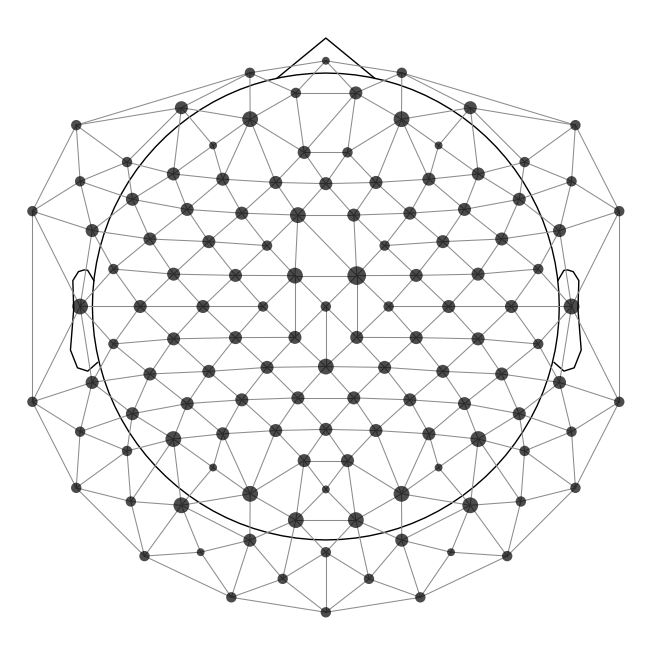

Numero medio di vicini per canale: 6.70


In [5]:

# === adjacency sparse ===
adjacency, _ = mne.channels.find_ch_adjacency(info, ch_type='eeg')

# Lista nomi canali
n_ch = len(ch_names)

# Plot dell'adjacency matrix
mne.viz.plot_ch_adjacency(info, adjacency, ch_names, kind='2d', edit=False)  # Delaunay triangulation --> 
plt.show()

# Calcolo numero medio di vicini per canale
num_neighbors = adjacency.sum(axis=0)  # somma lungo righe → numero di vicini per canale
mean_neighbors = num_neighbors.mean()
print(f"Numero medio di vicini per canale: {mean_neighbors:.2f}")


## CBPT ON FREQUENCY in DESYNCHRONIZATION CLUSTER

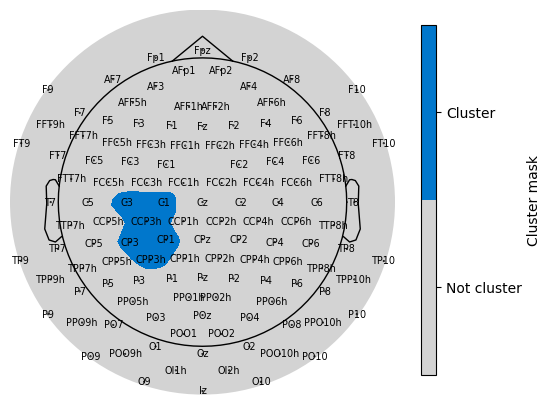

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import matplotlib as mpl

'''
LEFT_CLUSTER_CHANNELS = ['C1', 'C3', 'CCP3h', 'CCP5h', 'CP1', 'CP3', 'CPP3h', 'FCC1h', 'FCC3h', 'P1', 'P3', 'PPO1h']
RIGHT_CLUSTER_CHANNELS = ['CCP4h', 'CCP6h', 'CP4', 'CPP4h', 'CPP6h', 'P4', 'P6']
'''
# Cluster based on lower 5th percentile
LEFT_CLUSTER_CHANNELS = ['C1', 'C3', 'CCP3h', 'CP1', 'CP3', 'CPP3h']
RIGHT_CLUSTER_CHANNELS = []


CLUSTER_CHANNELS = LEFT_CLUSTER_CHANNELS + RIGHT_CLUSTER_CHANNELS

# --- Build binary mask ---
cluster_mask = np.array([1 if ch in CLUSTER_CHANNELS else 0 for ch in ch_names])

# --- Plot ---
fig, ax = plt.subplots(figsize=(5,5))

cmap = mpl.colors.ListedColormap(['lightgray', '#0077CC'])
norm = mpl.colors.Normalize(vmin=0, vmax=1)

im, _ = mne.viz.plot_topomap(
    cluster_mask,
    info,
    cmap=cmap,
    cnorm=norm,
    contours=0,
    sensors=True,
    axes=ax,
    names=ch_names,
    show=False
)

cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7]) 
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, ticks=[0.25, 0.75])
cbar.set_ticklabels(['Not cluster', 'Cluster'])
cbar.set_label("Cluster mask")

plt.show()

plt.show()


In [9]:


# Prendiamo info dal primo soggetto
subject0 = list(EEG_DATA_ALL.keys())[0]
montage = EEG_DATA_ALL[subject0][0]['montage']  

# Lista nomi canali
ch_names = montage.ch_names

cluster_idx = [ch_names.index(ch) for ch in CLUSTER_CHANNELS if ch in ch_names]
n_channels = len(CLUSTER_CHANNELS)

subject_list = list(eeg_psd_data_dict.keys())
phase_names = ["Rest", "Reach", "Grasp", "Pull"]

# --- Build uniform frequency array (from 1 to 80 Hz)
freq_uniform = np.linspace(1, 80, 160)
n_freqs = len(freq_uniform)
print("Frequenze uniformi:", freq_uniform.shape)

# Dict for all trials
ALL_TRIALS = {p: [] for p in phase_names}

# Extraction of PSD trials 
for subject_id in subject_list:

    freqs_orig = eeg_psd_data_dict[subject_id]['freqs']

    for p in range(len(phase_names)):
        
        # Array 
        psd_phase = np.mean(eeg_psd_data_dict[subject_id]['PSD_norm_all'][p, cluster_idx, :, :]*100, axis=0)

        # Cut frequencies 1–80 Hz
        freq_mask = (freqs_orig >= 1) & (freqs_orig <= 80)
        freqs_cut = freqs_orig[freq_mask]
        psd_phase_cut = psd_phase[:, freq_mask]   
        
        # Interpolation of the PSD to the regular lattice
        n_trials = psd_phase_cut.shape[0]
        psd_interp = np.zeros((n_trials, n_freqs)) 

        for t in range(n_trials):
            f = interp1d(freqs_cut,
                        psd_phase_cut[t, :],
                        kind='linear',
                        fill_value='extrapolate')
            psd_interp[t, :] = f(freq_uniform)

        ALL_TRIALS[phase_names[p]].append(psd_interp)

# Concatenation of all interpolated trials per subject and phase
for phase in phase_names:
    ALL_TRIALS[phase] = np.concatenate(ALL_TRIALS[phase], axis=0)
    print(f"{phase}: {ALL_TRIALS[phase].shape}")

# Build the adjacency matrix --> all frequencies are neighbours with the two closest ones (e.g. 2 Hz -> 1.5 Hz and 2.5 Hz )
adj = sparse.lil_matrix((n_freqs, n_freqs))

for i in range(n_freqs - 1):
    adj[i, i+1] = 1
    adj[i+1, i] = 1

adjacency_freq = adj.tocsr()

# Determine all phase pairs combinations (6)
phase_pairs = list(itertools.combinations(phase_names, 2))
ALL_RESULTS = {}

for phaseA, phaseB in phase_pairs:
    print(f"\nVisualizing trials: {phaseA} vs {phaseB}")
    
    trialsA = ALL_TRIALS[phaseA]  # shape: n_trials x n_freq
    trialsB = ALL_TRIALS[phaseB]  # shape: n_trials x n_freq

    print(f"\nRunning CBPT: {phaseA} vs {phaseB}")
    
    # Cluster permutation input (The first dimension should correspond to the difference between paired samples (observations) in two conditions)
    X_diff = trialsA - trialsB   # (trials × freq)

    pval = 0.05
    n_obs = X_diff.shape[0]
    df = n_obs - 1
    thresh = scipy.stats.t.ppf(1 - pval/2, df)

    T_obs, clusters, p_values, H0 = permutation_cluster_1samp_test(
        X_diff,
        n_permutations=10000,
        tail=0,
        adjacency=adjacency_freq,
        threshold=thresh,
        seed=0,
        out_type='mask',
        verbose=False
    )

    ALL_RESULTS[f"{phaseA}_vs_{phaseB}"] = {
        "T_obs": T_obs,
        "clusters": clusters,
        "p_values": p_values,
        "H0": H0
    }

    # --- Bonferroni correction ---
    n_tests = len(phase_pairs)  # tot number of tests
    ALL_RESULTS[f"{phaseA}_vs_{phaseB}"]["p_values_corrected"] = np.minimum(
        np.array(p_values) * n_tests, 1.0
    )

print("\n✔️ Completed CBPT for all phase pairs.")


Frequenze uniformi: (160,)
Rest: (229, 160)
Reach: (229, 160)
Grasp: (229, 160)
Pull: (229, 160)

Visualizing trials: Rest vs Reach

Running CBPT: Rest vs Reach

Visualizing trials: Rest vs Grasp

Running CBPT: Rest vs Grasp

Visualizing trials: Rest vs Pull

Running CBPT: Rest vs Pull

Visualizing trials: Reach vs Grasp

Running CBPT: Reach vs Grasp

Visualizing trials: Reach vs Pull

Running CBPT: Reach vs Pull

Visualizing trials: Grasp vs Pull

Running CBPT: Grasp vs Pull

✔️ Completed CBPT for all phase pairs.


In [10]:
# ============================
# PRINT ALL CLUSTERS FOUND
# ============================

print("\n==================== CLUSTER RESULTS ====================\n")

for comp, res in ALL_RESULTS.items():
    print(f"\n### {comp} ###")

    clusters = res["clusters"]
    pvals = res["p_values"]
    T_obs = res["T_obs"]

    if len(clusters) == 0:
        print("  → No clusters found.")
        continue

    for idx, cl in enumerate(clusters):
        mask = cl  # Boolean mask (freq dimension)
        p = pvals[idx]
        freqs_in_cluster = np.where(mask)[0]

        print(f"\n  Cluster {idx+1}:")
        print(f"    p-value       = {p:.4f}")
        print(f"    size          = {len(freqs_in_cluster)} bins")
        print(f"    freq range    = {freq_uniform[freqs_in_cluster[0]]:.2f}–{freq_uniform[freqs_in_cluster[-1]]:.2f} Hz")

        # opzionale: T-value medio nel cluster
        mean_T = T_obs[mask].mean()
        print(f"    mean T value  = {mean_T:.3f}")

print("\n==========================================================\n")



==================== CLUSTER RESULTS ====================


### Rest_vs_Reach ###

  Cluster 1:
    p-value       = 0.0089
    size          = 32 bins
    freq range    = 11.43–26.84 Hz
    mean T value  = 3.786

  Cluster 2:
    p-value       = 0.0521
    size          = 15 bins
    freq range    = 1.00–7.96 Hz
    mean T value  = -4.210

  Cluster 3:
    p-value       = 0.0001
    size          = 93 bins
    freq range    = 34.29–80.00 Hz
    mean T value  = -4.950

### Rest_vs_Grasp ###

  Cluster 1:
    p-value       = 0.0029
    size          = 27 bins
    freq range    = 14.91–27.83 Hz
    mean T value  = 4.949

  Cluster 2:
    p-value       = 0.0639
    size          = 13 bins
    freq range    = 1.00–6.96 Hz
    mean T value  = -4.101

  Cluster 3:
    p-value       = 0.0003
    size          = 59 bins
    freq range    = 51.18–80.00 Hz
    mean T value  = -3.691

### Rest_vs_Pull ###

  Cluster 1:
    p-value       = 0.1246
    size          = 13 bins
    freq range    = 17.

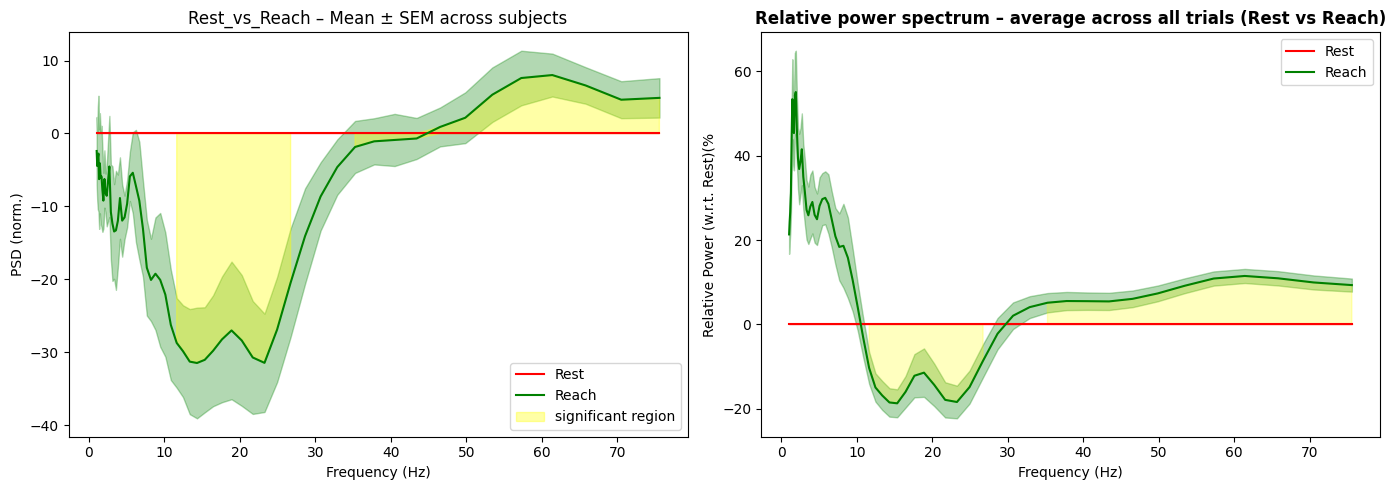


Significant frequencies for Rest vs Reach (CBPT):
  Cluster 1: freq = 11.43–26.84 Hz → p = 0.0089
  Cluster 2: freq = 1.00–7.96 Hz → p = 0.0521
  Cluster 3: freq = 34.29–80.00 Hz → p = 0.0001

Saved SIGNIFICANT_BANDS[Rest_vs_Reach]:
  11.43–26.84 Hz  (p=0.0089)
  34.29–80.00 Hz  (p=0.0001)


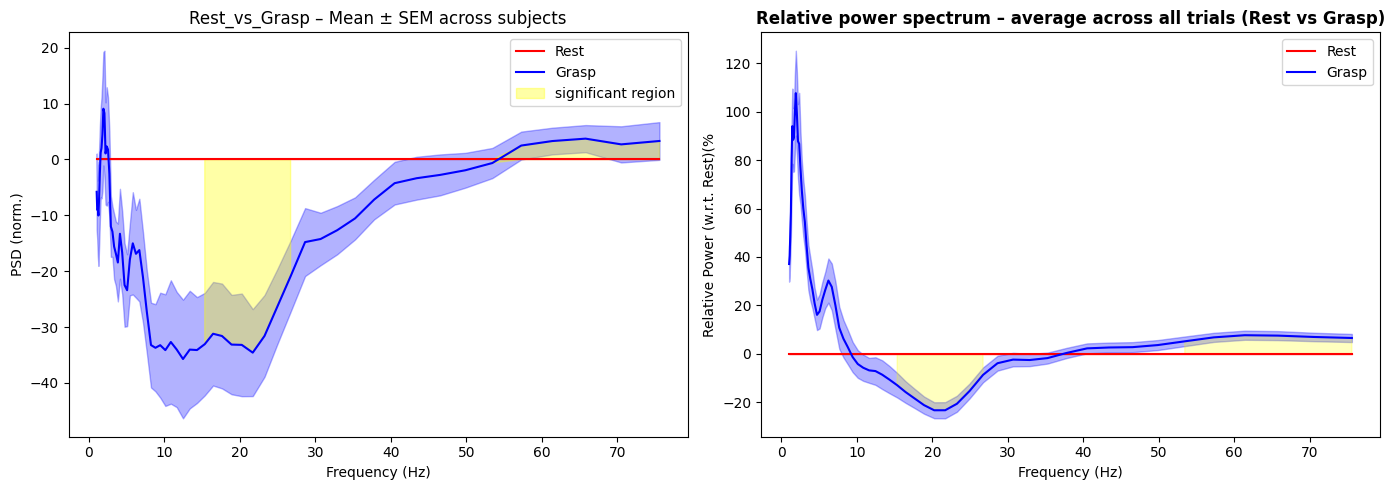


Significant frequencies for Rest vs Grasp (CBPT):
  Cluster 1: freq = 14.91–27.83 Hz → p = 0.0029
  Cluster 2: freq = 1.00–6.96 Hz → p = 0.0639
  Cluster 3: freq = 51.18–80.00 Hz → p = 0.0003

Saved SIGNIFICANT_BANDS[Rest_vs_Grasp]:
  14.91–27.83 Hz  (p=0.0029)
  51.18–80.00 Hz  (p=0.0003)


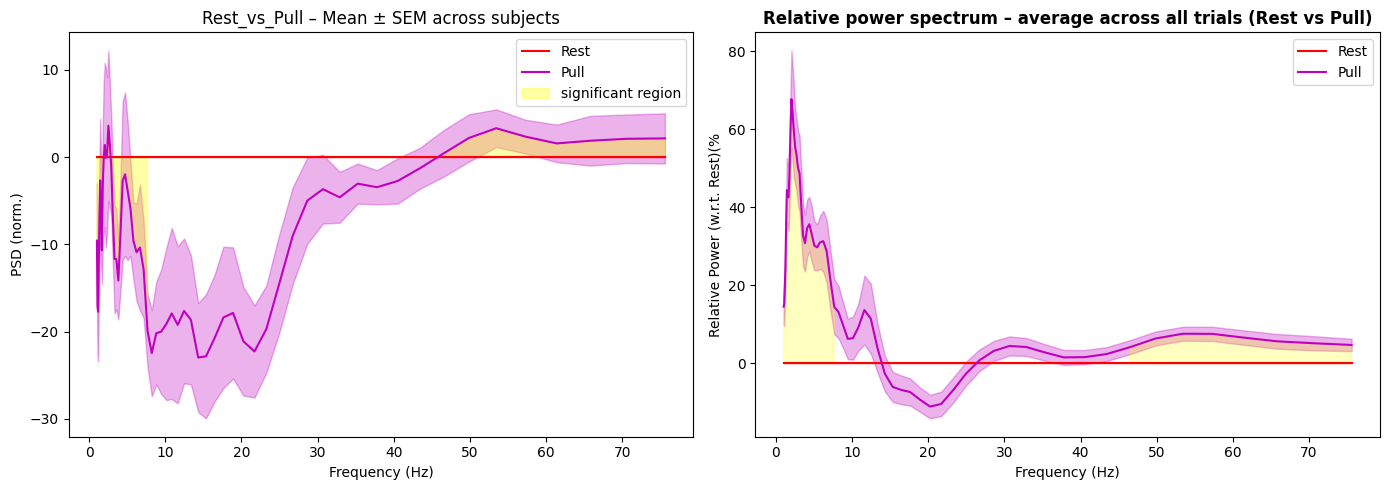


Significant frequencies for Rest vs Pull (CBPT):
  Cluster 1: freq = 17.40–23.36 Hz → p = 0.1246
  Cluster 2: freq = 1.00–7.96 Hz → p = 0.0434
  Cluster 3: freq = 45.72–80.00 Hz → p = 0.0001

Saved SIGNIFICANT_BANDS[Rest_vs_Pull]:
  1.00–7.96 Hz  (p=0.0434)
  45.72–80.00 Hz  (p=0.0001)


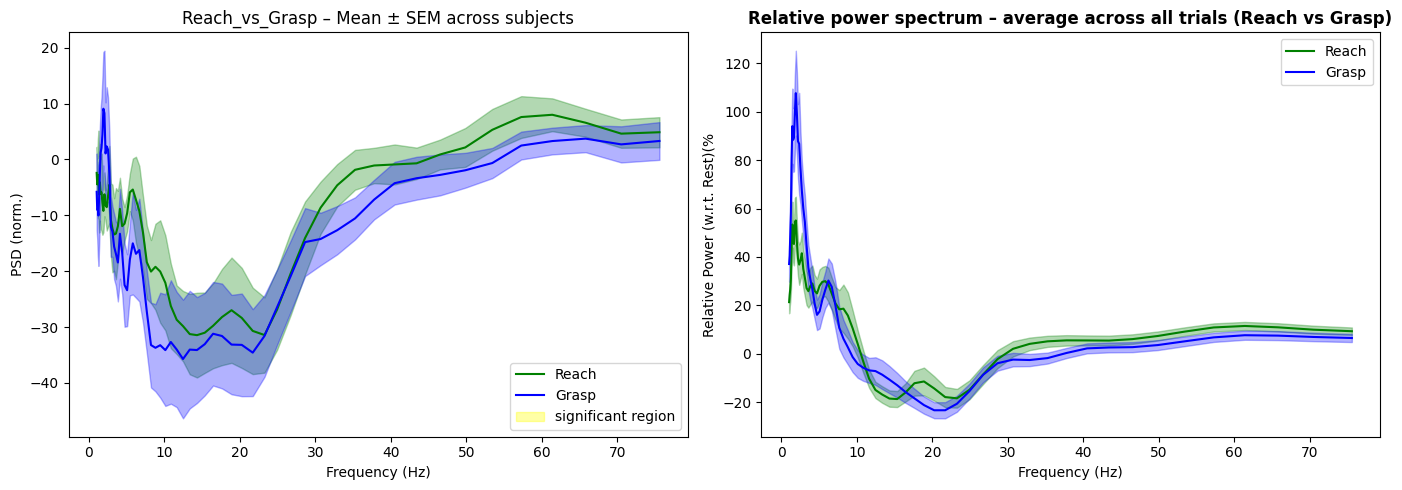


Significant frequencies for Reach vs Grasp (CBPT):
  Cluster 1: freq = 19.88–19.88 Hz → p = 0.7014
  Cluster 2: freq = 32.80–38.26 Hz → p = 0.1996
  Cluster 3: freq = 54.66–59.63 Hz → p = 0.2426
  Cluster 4: freq = 1.00–2.99 Hz → p = 0.2906

Saved SIGNIFICANT_BANDS[Reach_vs_Grasp]:


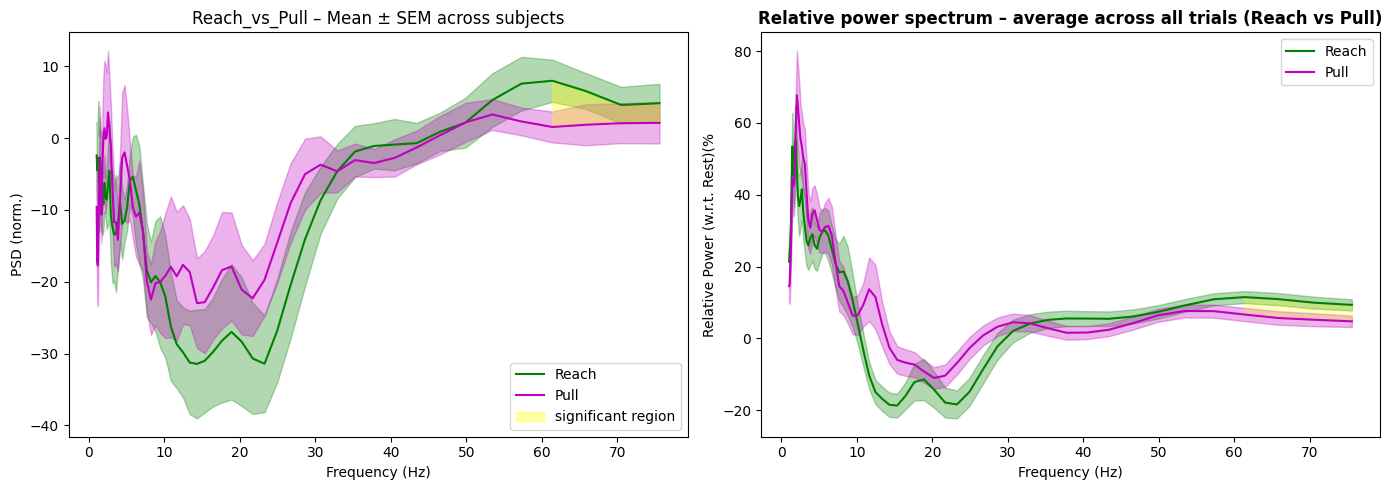


Significant frequencies for Reach vs Pull (CBPT):
  Cluster 1: freq = 59.63–80.00 Hz → p = 0.0129
  Cluster 2: freq = 2.49–2.49 Hz → p = 0.5905
  Cluster 3: freq = 10.94–16.40 Hz → p = 0.1198
  Cluster 4: freq = 21.87–27.33 Hz → p = 0.1496

Saved SIGNIFICANT_BANDS[Reach_vs_Pull]:
  59.63–80.00 Hz  (p=0.0129)


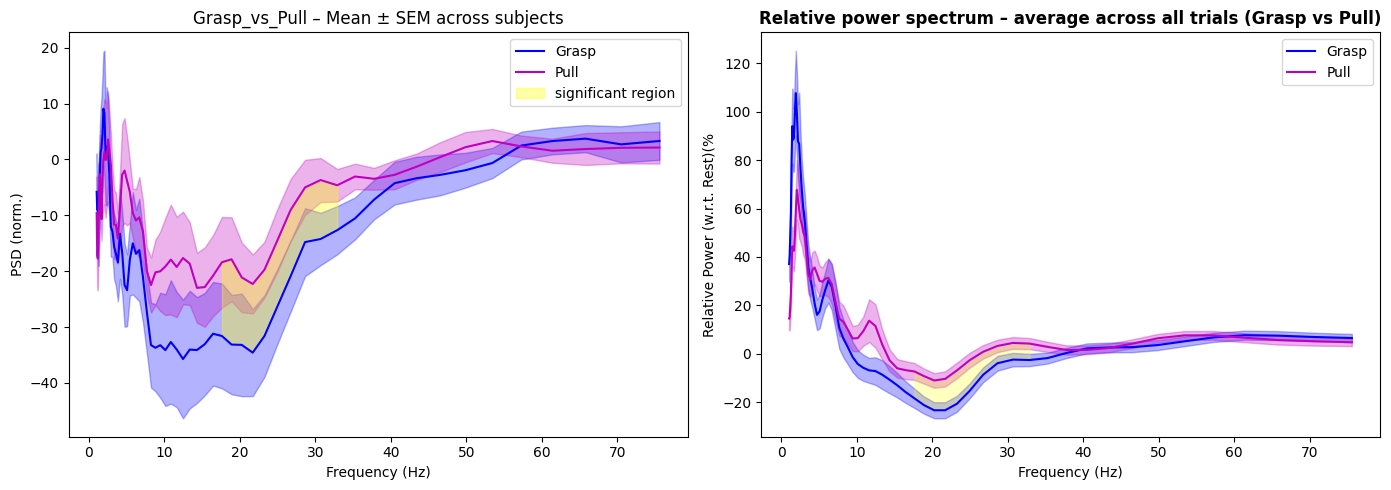


Significant frequencies for Grasp vs Pull (CBPT):
  Cluster 1: freq = 1.00–2.49 Hz → p = 0.3440
  Cluster 2: freq = 4.48–4.97 Hz → p = 0.5382
  Cluster 3: freq = 10.44–12.92 Hz → p = 0.3447
  Cluster 4: freq = 16.90–34.79 Hz → p = 0.0060

Saved SIGNIFICANT_BANDS[Grasp_vs_Pull]:
  16.90–34.79 Hz  (p=0.0060)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parametri generali
# -----------------------------
phase_colors = {
    'Rest':  'r',
    'Reach': 'g',
    'Grasp': 'b',
    'Pull':  'm'
}


# Cluster di canali
cluster_idx = [ch_names.index(ch) for ch in CLUSTER_CHANNELS if ch in ch_names]

# -----------------------------
# Ciclo sulle coppie di fasi
# -----------------------------
for comp_name, res in ALL_RESULTS.items():
    phaseA, phaseB = comp_name.split('_vs_')
    
    # 1️⃣ Media PSD per soggetto, mediana sui trials e media cluster
    psdA_all = []
    psdB_all = []

    psdA_all_cluster = []
    psdB_all_cluster = []

    for subj in subject_list:
        phase_idxA = phase_names.index(phaseA)
        phase_idxB = phase_names.index(phaseB)

        freqs_orig_full = eeg_psd_data_dict[subj]['freqs']

        # trova indici tra 1 e 80 Hz
        valid_idx = np.where((freqs_orig_full >= 1) & (freqs_orig_full <= 80))[0]

        # taglia le frequenze
        freqs_orig = freqs_plot = freqs_orig_full[valid_idx]

        # PSD_norm_all: channels × trials × freqs
        psdA_trials_full = eeg_psd_data_dict[subj]['PSD_norm_all'][phase_idxA, cluster_idx, :, :]*100
        psdB_trials_full = eeg_psd_data_dict[subj]['PSD_norm_all'][phase_idxB, cluster_idx, :, :]*100

        # taglia le PSD sui trial
        psdA_trials = psdA_trials_full[:, :, valid_idx]
        psdB_trials = psdB_trials_full[:, :, valid_idx]
        
        # Interpolazione su freq_uniform
        n_trialsA = psdA_trials.shape[1]
        n_trialsB = psdB_trials.shape[1]

        # Mediana tra trials per canale
        psdA_median = np.median(psdA_trials, axis=1)  # cluster x freqs
        psdB_median = np.median(psdB_trials, axis=1)
        
        # Media tra canali del cluster
        psdA_mean_cluster = psdA_median.mean(axis=0)
        psdB_mean_cluster = psdB_median.mean(axis=0)
        
        psdA_all.append(psdA_mean_cluster)
        psdB_all.append(psdB_mean_cluster)

        psdA_all_cluster.append(psdA_trials.mean(axis=0))  # trials × freqs
        psdB_all_cluster.append(psdB_trials.mean(axis=0))

    # Ora np.stack funziona
    psdA_all = np.stack(psdA_all, axis=0)
    psdB_all = np.stack(psdB_all, axis=0)

    # 2️⃣ Media e SEM tra soggetti
    psdA_mean = psdA_all.mean(axis=0)
    psdA_sem  = psdA_all.std(axis=0, ddof=1) / np.sqrt(len(subject_list))
    psdB_mean = psdB_all.mean(axis=0)
    psdB_sem  = psdB_all.std(axis=0, ddof=1) / np.sqrt(len(subject_list))

    # Media e SEM tra tutti i trials
    all_trials_A = np.concatenate(psdA_all_cluster, axis=0)  
    all_trials_B = np.concatenate(psdB_all_cluster, axis=0)

    mean_A_t = all_trials_A.mean(axis=0)
    sem_A_t  = all_trials_A.std(axis=0, ddof=1) / np.sqrt(all_trials_A.shape[0])

    mean_B_t = all_trials_B.mean(axis=0)
    sem_B_t  = all_trials_B.std(axis=0, ddof=1) / np.sqrt(all_trials_B.shape[0])


    # 3️⃣ Frequenze significative CBPT
    sig_mask = np.zeros_like(freqs_plot, dtype=bool)
    freqs_cbpt = np.linspace(1, 80, 160)

    for cl_mask, p_val in zip(res['clusters'], res['p_values']):
        if p_val < 0.05:

            # individua gli indici del cluster originale
            freq_idx = np.where(cl_mask)[0]

            # estrai range reale del cluster
            f_low  = freqs_cbpt[freq_idx[0]]
            f_high = freqs_cbpt[freq_idx[-1]]

            # nuova maschera basata sulle frequenze del plot
            sig_mask |= (freqs_plot >= f_low) & (freqs_plot <= f_high)

    # 4️⃣ Plot
    plt.figure(figsize=(14,5))

    # ------------------------------------------
    # Subplot PSD ± SEM + banda unica tra curve
    # ------------------------------------------
    plt.subplot(1,2,1)

    # Curve
    plt.plot(freqs_plot, psdA_mean, color=phase_colors[phaseA], label=phaseA)
    plt.fill_between(freqs_plot, psdA_mean - psdA_sem, psdA_mean + psdA_sem,
                    color=phase_colors[phaseA], alpha=0.3)

    plt.plot(freqs_plot, psdB_mean, color=phase_colors[phaseB], label=phaseB)
    plt.fill_between(freqs_plot, psdB_mean - psdB_sem, psdB_mean + psdB_sem,
                    color=phase_colors[phaseB], alpha=0.3)

    # ------------------------------------------
    # ⭐ Banda unica tra le due curve (gialla)
    # ------------------------------------------
    low_curve  = np.minimum(psdA_mean, psdB_mean)
    high_curve = np.maximum(psdA_mean, psdB_mean)

    plt.fill_between(freqs_plot,
                    low_curve,
                    high_curve,
                    where=sig_mask,
                    color='yellow',
                    alpha=0.35,
                    label='significant region')

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD (norm.)")
    plt.title(f"{comp_name} – Mean ± SEM across subjects")
    plt.legend()
    plt.grid(False)

    # --------------------------------------------------------
    # SUBPLOT 2: PSD media sui TRIALS concatenati
    # --------------------------------------------------------
    plt.subplot(1,2,2)


    # Plot fase A
    plt.plot(freqs_plot, mean_A_t, color=phase_colors[phaseA], label=f"{phaseA}")
    plt.fill_between(freqs_plot,
                    mean_A_t - sem_A_t,
                    mean_A_t + sem_A_t,
                    color=phase_colors[phaseA], alpha=0.3)

    # Plot fase B
    plt.plot(freqs_plot, mean_B_t, color=phase_colors[phaseB], label=f"{phaseB}")
    plt.fill_between(freqs_plot,
                    mean_B_t - sem_B_t,
                    mean_B_t + sem_B_t,
                    color=phase_colors[phaseB], alpha=0.3)

    # Evidenzia regioni significative CBPT
    if np.any(sig_mask):
        diff_low  = np.minimum(mean_A_t, mean_B_t)
        diff_high = np.maximum(mean_A_t, mean_B_t)
        plt.fill_between(freqs_plot, diff_low, diff_high,
                        where=sig_mask, color='yellow', alpha=0.25)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Relative Power (w.r.t. Rest)(%")
    plt.title(f"Relative power spectrum – average across all trials ({phaseA} vs {phaseB})", fontweight='bold')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    
    print(f"\nSignificant frequencies for {comp_name.replace('_', ' ')} (CBPT):")

    clusters = res["clusters"]
    pvals    = res["p_values"]


    if len(clusters) == 0:
        print("  → No significant clusters found.")
    else:
        for idx, cl in enumerate(clusters):
            mask = cl
            p = pvals[idx]

            freqs_idx = np.where(mask)[0]

            f_min = freqs_cbpt[freqs_idx[0]]
            f_max = freqs_cbpt[freqs_idx[-1]]

            print(f"  Cluster {idx+1}: freq = {f_min:.2f}–{f_max:.2f} Hz → p = {p:.4f}")

    # ======================================================
    # COSTRUZIONE DEL DIZIONARIO SIGNIFICANT_BANDS
    # ======================================================

    if 'SIGNIFICANT_BANDS' not in globals():
        SIGNIFICANT_BANDS = {}

    pair_key = f"{phaseA}_vs_{phaseB}"
    SIGNIFICANT_BANDS[pair_key] = []

    clusters = res["clusters"]
    pvals    = res["p_values"]


    if len(clusters) == 0:
        print(f" → No significant clusters stored for {pair_key}.")
    else:
        for idx, cl in enumerate(clusters):
            if pvals[idx] < 0.05:

                mask = cl
                freq_idx = np.where(mask)[0]

                low_f  = float(freqs_cbpt[freq_idx[0]])
                high_f = float(freqs_cbpt[freq_idx[-1]])
                p_val  = float(pvals[idx])

                SIGNIFICANT_BANDS[pair_key].append({
                    "low_freq": low_f,
                    "high_freq": high_f,
                    "p_value": p_val
                })

        # Stampa riassuntiva
        print(f"\nSaved SIGNIFICANT_BANDS[{pair_key}]:")
        for b in SIGNIFICANT_BANDS[pair_key]:
            print(f"  {b['low_freq']:.2f}–{b['high_freq']:.2f} Hz  (p={b['p_value']:.4f})")


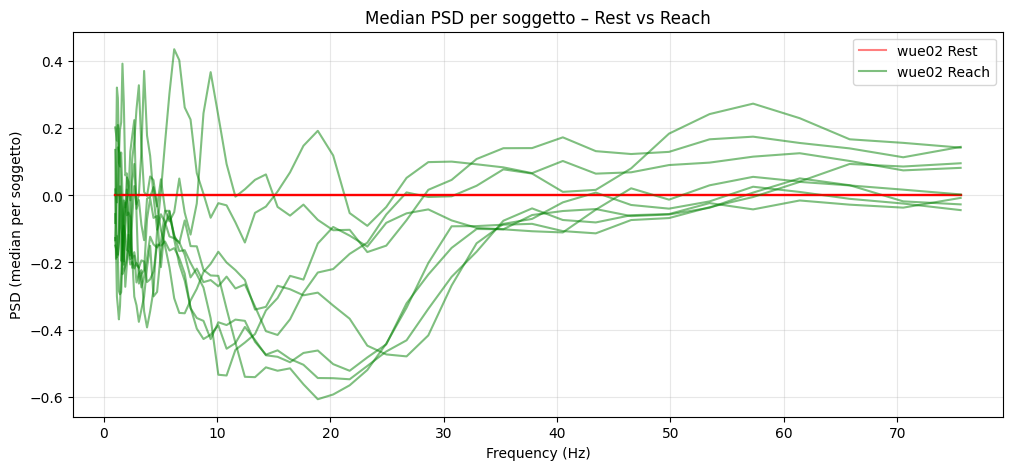

In [14]:
# Prendi la prima coppia di fasi
first_pair = list(ALL_RESULTS.keys())[0]
phaseA, phaseB = first_pair.split('_vs_')

# Prepariamo i dati per soggetto
subject_medians_A = []
subject_medians_B = []

for subj in subject_list:
    phase_idxA = phase_names.index(phaseA)
    phase_idxB = phase_names.index(phaseB)

    # PSD selezione cluster e frequenze 1-80 Hz
    valid_idx = np.where((eeg_psd_data_dict[subj]['freqs'] >= 1) & 
                         (eeg_psd_data_dict[subj]['freqs'] <= 80))[0]
    freqs_plot = eeg_psd_data_dict[subj]['freqs'][valid_idx]

    psdA_trials = eeg_psd_data_dict[subj]['PSD_norm_all'][phase_idxA, cluster_idx, :, :][:, :, valid_idx]
    psdB_trials = eeg_psd_data_dict[subj]['PSD_norm_all'][phase_idxB, cluster_idx, :, :][:, :, valid_idx]

    # Mediana tra trials per canale, poi media cluster
    psdA_median = np.median(psdA_trials, axis=1).mean(axis=0)
    psdB_median = np.median(psdB_trials, axis=1).mean(axis=0)

    subject_medians_A.append(psdA_median)
    subject_medians_B.append(psdB_median)

# Stack in array soggetti × freq
subject_medians_A = np.stack(subject_medians_A, axis=0)
subject_medians_B = np.stack(subject_medians_B, axis=0)

# Plot separato
plt.figure(figsize=(12,5))
for i, subj in enumerate(subject_list):
    plt.plot(freqs_plot, subject_medians_A[i], color='r', alpha=0.5, label=f"{subj} {phaseA}" if i==0 else "")
    plt.plot(freqs_plot, subject_medians_B[i], color='g', alpha=0.5, label=f"{subj} {phaseB}" if i==0 else "")

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (median per soggetto)")
plt.title(f"Median PSD per soggetto – {phaseA} vs {phaseB}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Generating global PSD comparison across all phases...



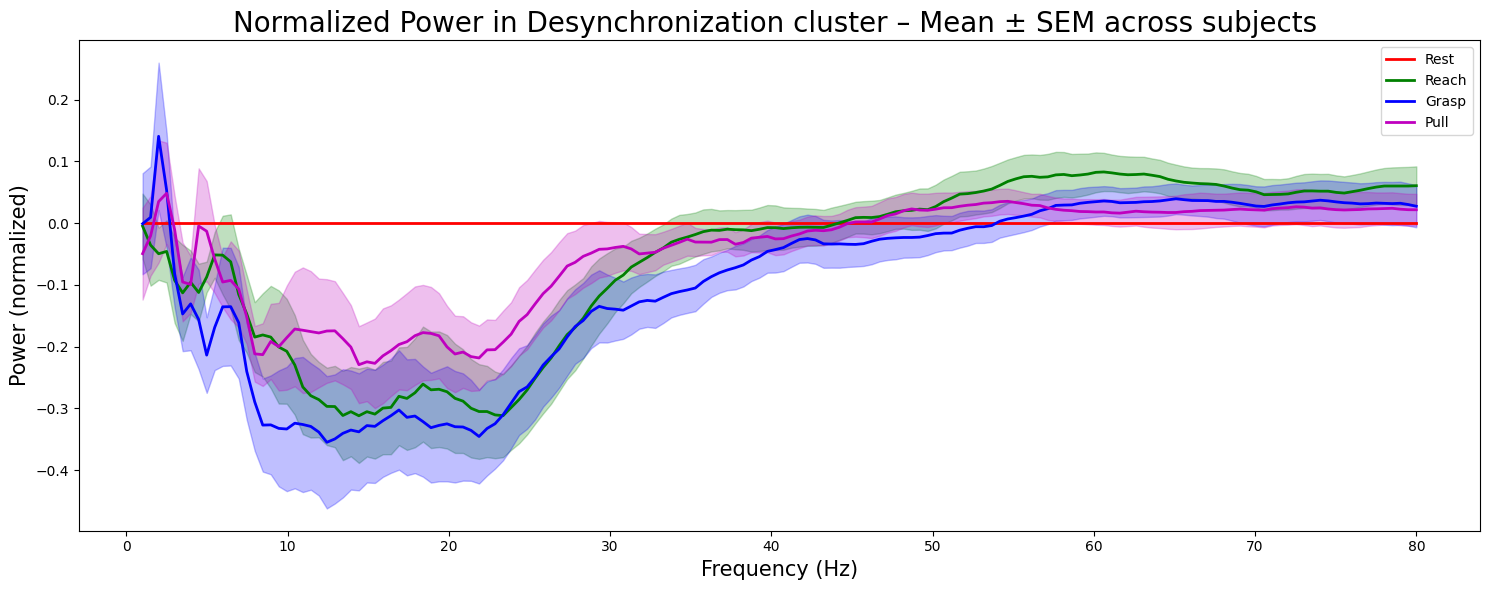

In [10]:
# ==========================================
# 📌 PLOT UNICO CON TUTTE LE FASI (mean PSD)
# ==========================================

print("\nGenerating global PSD comparison across all phases...\n")

# Struttura per salvare PSD per ogni fase
phase_psd_subject = {ph: [] for ph in phase_names}

# Loop su soggetti e fasi per estrarre tutte le PSD
for subj in subject_list:
    freqs_orig = eeg_psd_data_dict[subj]['freqs']
    for ph_idx, ph in enumerate(phase_names):

        psd_trials = eeg_psd_data_dict[subj]['PSD_norm_all'][ph_idx, cluster_idx, :, :]  # cluster × trials × freqs
        n_trials = psd_trials.shape[1]

        # Interpolazione su freq_uniform
        psd_interp = np.zeros((len(cluster_idx), n_trials, len(freq_uniform)))

        for ch in range(len(cluster_idx)):
            for t in range(n_trials):
                f_interp = interp1d(freqs_orig, psd_trials[ch, t, :], 
                                    kind='linear', fill_value='extrapolate')
                psd_interp[ch, t, :] = f_interp(freq_uniform)

        # Mediana tra per-trial
        psd_median = np.median(psd_interp, axis=1)  # cluster × freqs

        # Media tra canali del cluster
        psd_mean_cluster = psd_median.mean(axis=0)

        phase_psd_subject[ph].append(psd_mean_cluster)

# Converte in array: n_subjects × freqs
for ph in phase_names:
    phase_psd_subject[ph] = np.stack(phase_psd_subject[ph], axis=0)

# Calcolo media e SEM
phase_mean = {ph: phase_psd_subject[ph].mean(axis=0) for ph in phase_names}
phase_sem  = {ph: phase_psd_subject[ph].std(axis=0, ddof=1) / np.sqrt(len(subject_list)) 
              for ph in phase_names}

# ==========================
# PLOT UNICO PER TUTTE LE FASI
# ==========================
plt.figure(figsize=(15,6))

for ph in phase_names:
    m = phase_mean[ph]
    s = phase_sem[ph]
    plt.plot(freq_uniform, m, color=phase_colors[ph], label=ph, linewidth=2)
    plt.fill_between(freq_uniform, m - s, m + s, color=phase_colors[ph], alpha=0.25)

plt.xlabel("Frequency (Hz)", fontsize=15)
plt.ylabel("Power (normalized)", fontsize=15)
plt.title("Normalized Power in Desynchronization cluster – Mean ± SEM across subjects ", fontsize=20)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
from scipy.stats import wilcoxon, shapiro, ttest_rel
import scipy.stats as stats
import matplotlib.pyplot as plt

phase_names = ['Rest', 'Reach', 'Grasp', 'Pull']
phase_pairs = [(phase_names[i], phase_names[j]) 
               for i in range(len(phase_names)) 
               for j in range(i+1, len(phase_names))]

STATS = {}

for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in SIGNIFICANT_BANDS:
        continue

    print(f"\n=== {pair_key} ===")

    STATS[pair_key] = []

    # bande significative rilevate dal CBPT
    bands = SIGNIFICANT_BANDS[pair_key]

    for band in bands:

        low_f = band['low_freq']
        high_f = band['high_freq']

        vals_A = []
        vals_B = []

        

        for subj in subject_list:
            # ----------------------------------------
            # Estraggo la PSD: phases × channels × trials × freqs
            # ----------------------------------------
            psd_subj = eeg_psd_data_dict[subj]['PSD_norm_all']*100  # phases × channels × trials × freqs

            # Prendo le fasi corrette
            pA_idx = phase_names.index(phaseA)
            pB_idx = phase_names.index(phaseB)

            # Estraggo PSD nei canali del cluster
            psdA_med = psd_subj[pA_idx, cluster_idx, :, :] 
            psdB_med = psd_subj[pB_idx, cluster_idx, :, :]

            # Media tra canali del cluster → freqs
            psdA_mean_ch = psdA_med.mean(axis=0)
            psdB_mean_ch = psdB_med.mean(axis=0)

            # Freq uniformi usate nel CBPT
            freqs = eeg_psd_data_dict[subj]['freqs']
            mask = (freqs >= low_f) & (freqs <= high_f)

            '''
            # Mediana tra trials
            psdA_median = np.median(psdA_mean_ch, axis=0)
            psdB_median = np.median(psdB_mean_ch, axis=0)

            vals_A.append(np.mean(psdA_median[mask]))
            vals_B.append(np.mean(psdB_median[mask]))

            '''
            # Media sulla banda
            psdA_mean_fr = np.mean(psdA_mean_ch[:,mask], axis=1)
            psdB_mean_fr = np.mean(psdB_mean_ch[:,mask], axis=1)

            vals_A.append(np.median(psdA_mean_fr))
            vals_B.append(np.median(psdB_mean_fr))
            

        vals_A = np.array(vals_A)
        vals_B = np.array(vals_B)
        diffs = vals_A - vals_B

        stat, p_val = ttest_rel(vals_A, vals_B)
        chosen_test = "paired t-test"


        STATS[pair_key].append({
            "band": (low_f, high_f),
            "test_used": chosen_test,
            "p_value": p_val,
            "median_A": float(np.median(vals_A)),
            "median_B": float(np.median(vals_B)),
            "all_vals_A": vals_A.tolist(),
            "all_vals_B": vals_B.tolist()
        })

        print(f"Banda {low_f:.2f}-{high_f:.2f} Hz:")
        print(f"  Test = {chosen_test}, p = {p_val:.5f}")
        print(f"  Median A={np.median(vals_A):.4f}, Median B={np.median(vals_B):.4f}")



=== Rest_vs_Reach ===
Banda 11.43-26.84 Hz:
  Test = paired t-test, p = 0.01611
  Median A=0.0000, Median B=-24.0816
Banda 34.29-80.00 Hz:
  Test = paired t-test, p = 0.10256
  Median A=0.0000, Median B=2.8857

=== Rest_vs_Grasp ===
Banda 14.91-27.83 Hz:
  Test = paired t-test, p = 0.01842
  Median A=0.0000, Median B=-28.6461
Banda 51.18-80.00 Hz:
  Test = paired t-test, p = 0.07470
  Median A=0.0000, Median B=6.6471

=== Rest_vs_Pull ===
Banda 1.00-7.96 Hz:
  Test = paired t-test, p = 0.00571
  Median A=0.0000, Median B=20.4710
Banda 45.72-80.00 Hz:
  Test = paired t-test, p = 0.08299
  Median A=0.0000, Median B=4.8169

=== Reach_vs_Grasp ===

=== Reach_vs_Pull ===
Banda 59.63-80.00 Hz:
  Test = paired t-test, p = 0.44514
  Median A=9.9759, Median B=4.3798

=== Grasp_vs_Pull ===
Banda 16.90-34.79 Hz:
  Test = paired t-test, p = 0.07401
  Median A=-21.7593, Median B=-9.1245


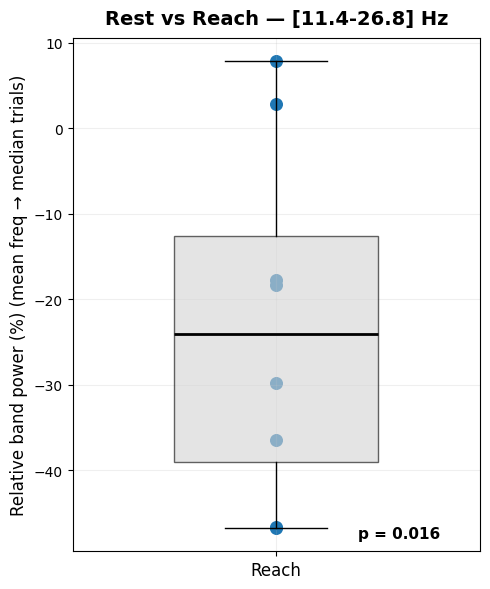

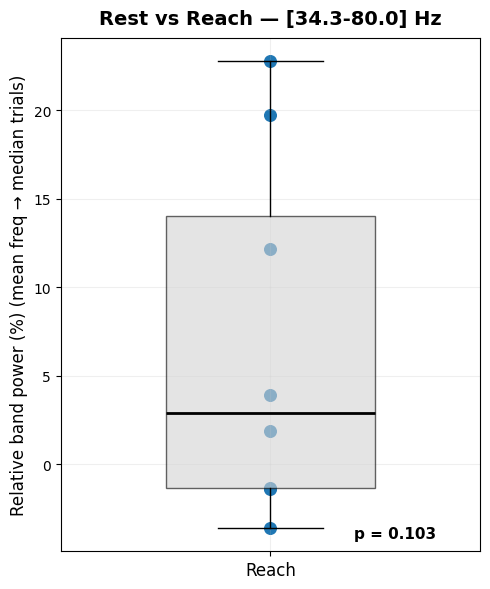

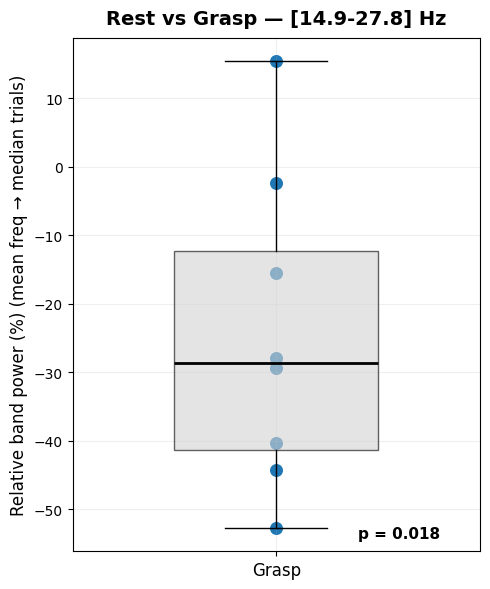

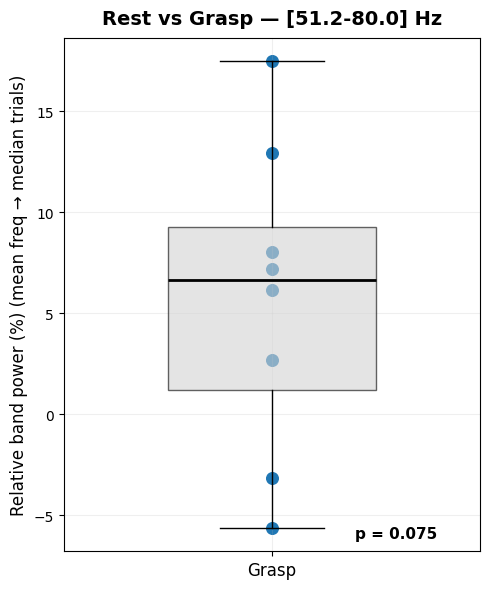

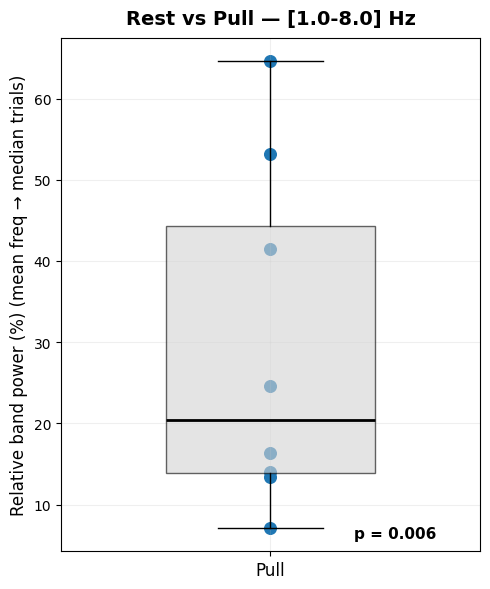

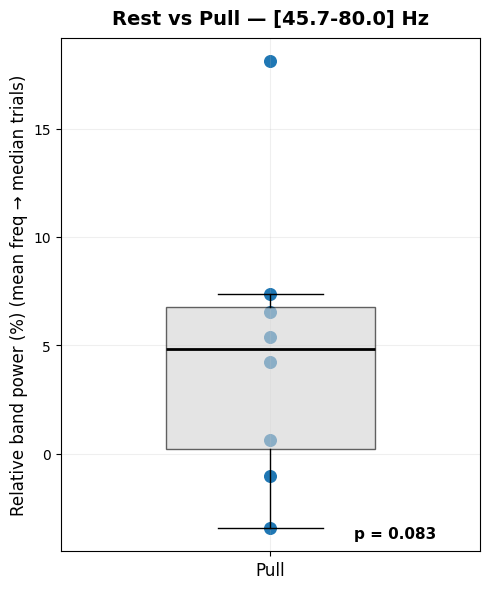

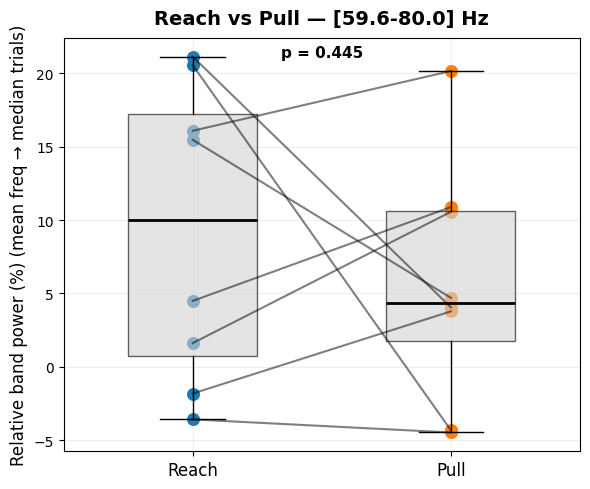

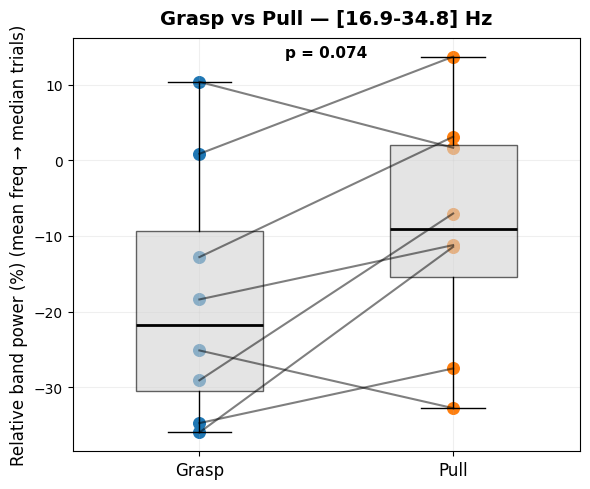

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# === Plot dei box-plot per i risultati salvati in STATS ===

for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in STATS:
        continue

    for item in STATS[pair_key]:

        low_f, high_f = item["band"]
        vals_A = np.array(item["all_vals_A"])
        vals_B = np.array(item["all_vals_B"])
        p_value = item["p_value"]

        title_band = f"[{low_f:.1f}-{high_f:.1f}] Hz"

        # =====================================================
        #  CASO SPECIALE: confronti con Rest → UN SOLO BOXPLOT
        # =====================================================
        if phaseA == "Rest" or phaseB == "Rest":

            # Determina la fase non-Rest
            if phaseA == "Rest":
                phase_plot = phaseB
                vals_plot = vals_B - vals_A     # differenza rispetto a Rest
            else:
                phase_plot = phaseA
                vals_plot = vals_A - vals_B

            boxprops = dict(facecolor='white', edgecolor='black', linewidth=1.2)
            medianprops = dict(color='black', linewidth=2)
            whiskerprops = dict(color='black', linewidth=1)
            capprops = dict(color='black', linewidth=1)

            plt.figure(figsize=(5, 6))

            # Boxplot singolo
            plt.boxplot(vals_plot, positions=[1], widths=0.5,
                        showfliers=False, patch_artist=True,
                        boxprops=dict(facecolor='lightgray', alpha=0.6),
                        medianprops=medianprops, whiskerprops=whiskerprops,
                        capprops=capprops)

            # Scatter dei soggetti
            plt.scatter(np.full(len(vals_plot), 1), vals_plot, s=70)

            plt.xticks([1], [phase_plot], fontsize=12)
            plt.ylabel("Relative band power (%) (mean freq → median trials)", fontsize=12)
            plt.title(f"{phaseA} vs {phaseB} — {title_band}", fontsize=14, fontweight='bold', pad=10)
            plt.grid(alpha=0.2)

            # --- p-value in basso a destra come esempio ---
            y_min, y_max = plt.ylim()
            plt.text(
                1.20,
                y_min + 0.02*(y_max - y_min),
                f"p = {p_value:.3f}",
                ha='left', va='bottom', fontsize=11, fontweight='bold'
            )

            plt.tight_layout()
            plt.show()
            continue   
        
        # =====================================================
        #  CASO NORMALE: due fasi NON Rest → due boxplot
        # =====================================================

        plt.figure(figsize=(6,5))
        positions=[1,2]

        plt.boxplot([vals_A, vals_B], positions=positions, widths=0.5,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='lightgray',alpha=0.6),
                    medianprops=medianprops, whiskerprops=whiskerprops,
                    capprops=capprops)


        plt.scatter(np.full(len(vals_A),positions[0]), vals_A, s=70)
        plt.scatter(np.full(len(vals_B),positions[1]), vals_B, s=70)

        for a,b in zip(vals_A, vals_B):
            plt.plot([1,2],[a,b],'k-',alpha=0.5)

        plt.xticks(positions,[phaseA,phaseB],fontsize=12)
        plt.ylabel("Relative band power (%) (mean freq → median trials)",fontsize=12)
        plt.title(f"{phaseA} vs {phaseB} — {title_band}", fontsize=14, fontweight='bold', pad=10)
        plt.grid(alpha=0.2)

        y_pos = max(max(vals_A),max(vals_B)) * 1.00
        plt.text(1.5, y_pos, f"p = {p_value:.3f}",
                 ha='center', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.show()


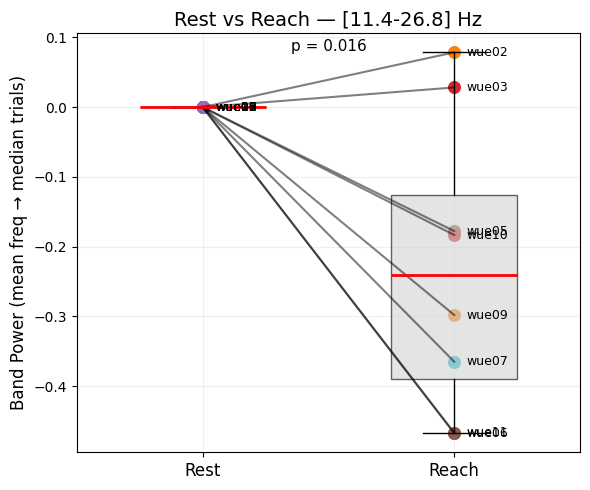

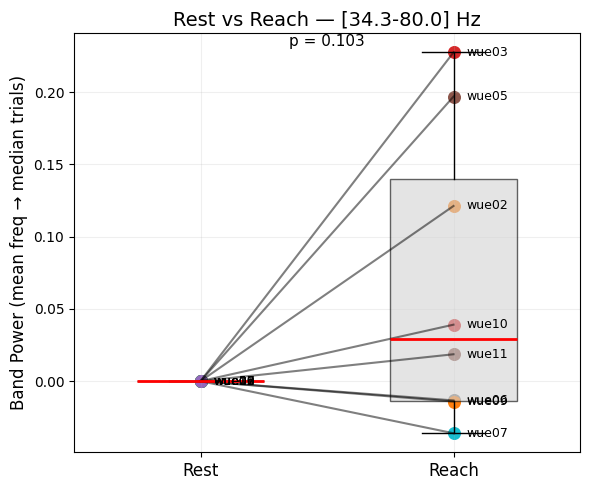

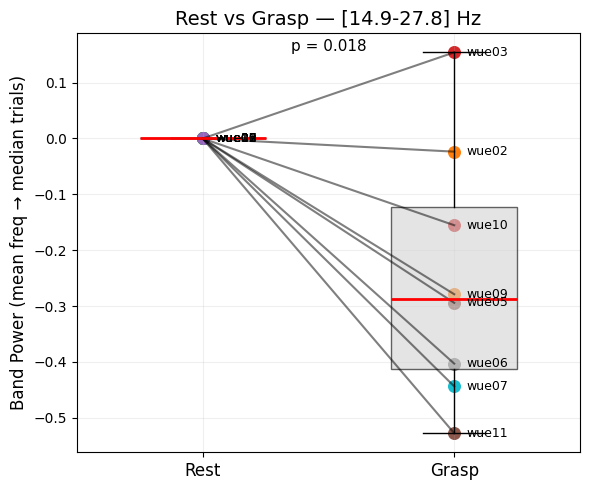

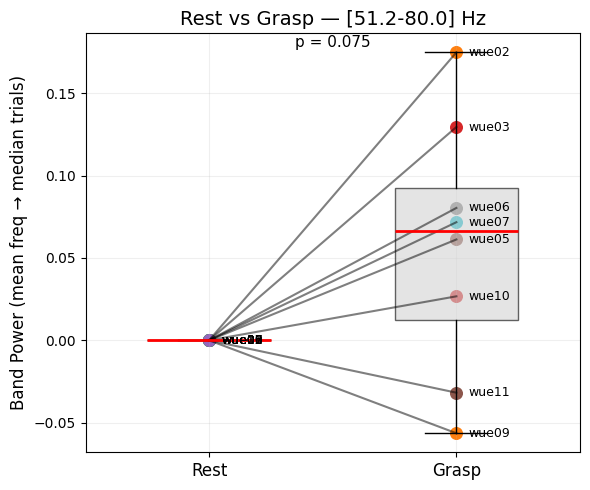

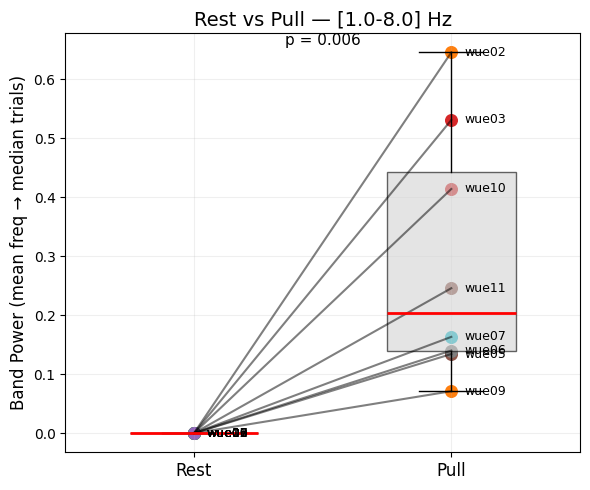

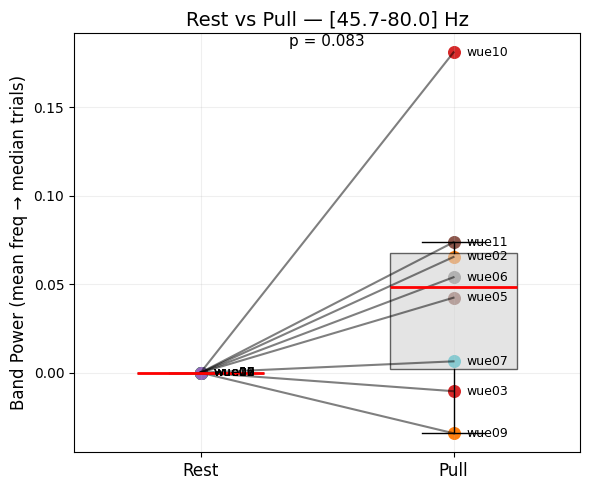

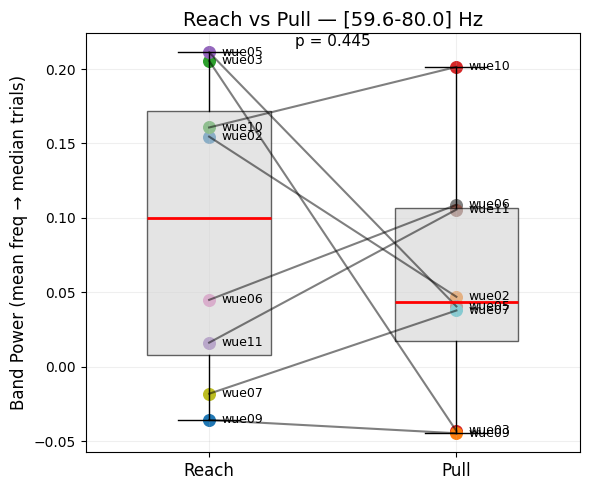

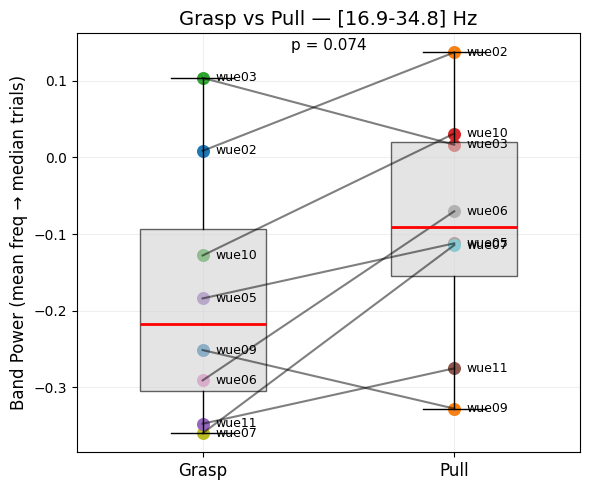

In [13]:

# === Plot dei box-plot per i risultati salvati in STATS ===

for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in STATS:
        continue

    for item in STATS[pair_key]:

        low_f, high_f = item["band"]
        vals_A = np.array(item["all_vals_A"])
        vals_B = np.array(item["all_vals_B"])
        p_value = item["p_value"]

        title_band = f"[{low_f:.1f}-{high_f:.1f}] Hz"

        # === FIGURA ===
        plt.figure(figsize=(6,5))
        positions=[1,2]

        plt.boxplot([vals_A, vals_B], positions=positions, widths=0.5,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='lightgray',alpha=0.6),
                    medianprops=dict(color='red',linewidth=2))

        # Scatter con etichette soggetto 🔥
        for i,(a,b) in enumerate(zip(vals_A, vals_B)):
            subj = subject_list[i]

            # Plot puntini
            plt.scatter(positions[0], a, s=70)
            plt.scatter(positions[1], b, s=70)

            # Etichette vicino al punto
            plt.text(positions[0]+0.05, a, subj, fontsize=9, va='center')
            plt.text(positions[1]+0.05, b, subj, fontsize=9, va='center')

            # Linea che collega A→B
            plt.plot([positions[0], positions[1]], [a, b], color='black', alpha=0.5)

        plt.xticks(positions,[phaseA,phaseB],fontsize=12)
        plt.ylabel("Band Power (mean freq → median trials)",fontsize=12)
        plt.title(f"{phaseA} vs {phaseB} — {title_band}",fontsize=14)
        plt.grid(alpha=0.2)

        # 🔥 p-value vicino al centro
        y_pos = max(max(vals_A),max(vals_B)) * 1.02
        plt.text(1.5, y_pos, f"p = {item['p_value']:.3f}",
                ha='center',fontsize=11)

        plt.tight_layout()
        plt.show()
